In [1]:
# ============================================================
# Benchmark empirical Bowen-Dinburg separated-orbit entropy
# on maps with known topological entropy
#
# Manuscript figure generated:
# benchmark_entropy_growth_rate_known_systems.jpeg/pdf
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# ============================================================
# Settings
# ============================================================

np.random.seed(42)

# Number of sampled initial conditions, called Q in the manuscript
Q = 20000

# Trajectory lengths used for slope estimation
n_values = [4, 5, 6, 7, 8, 10, 12]

# Separation scales
eps_values = [0.005, 0.01, 0.02, 0.05, 0.1]

# Greedy repetitions for estimating S_Q(n, epsilon)
n_greedy_repeats = 50

# Output files
benchmark_csv = "benchmark_empirical_BD_entropy_known_systems.csv"
slope_csv = "benchmark_entropy_slope_estimates.csv"
figure_jpeg = "benchmark_entropy_growth_rate_known_systems.jpeg"
figure_pdf = "benchmark_entropy_growth_rate_known_systems.pdf"


# ============================================================
# Maps with known entropy
# ============================================================

def identity_map(x):
    return x

def contraction_map(x):
    return 0.5 * x

def tent_map_full(x):
    return 1.0 - 2.0 * np.abs(x - 0.5)

def logistic_map_full(x):
    return 4.0 * x * (1.0 - x)

systems = {
    "identity_h0": {
        "map": identity_map,
        "true_entropy": 0.0
    },
    "contraction_h0": {
        "map": contraction_map,
        "true_entropy": 0.0
    },
    "tent_h_log2": {
        "map": tent_map_full,
        "true_entropy": np.log(2.0)
    },
    "logistic_h_log2": {
        "map": logistic_map_full,
        "true_entropy": np.log(2.0)
    }
}

system_order = [
    "identity_h0",
    "contraction_h0",
    "tent_h_log2",
    "logistic_h_log2"
]

pretty_names = {
    "identity_h0": "Identity\nh=0",
    "contraction_h0": "Contraction\nh=0",
    "tent_h_log2": "Tent map\nh=log 2",
    "logistic_h_log2": "Logistic map\nh=log 2"
}


# ============================================================
# Trajectory generation
# ============================================================

def generate_map_trajectories(map_function, Q, n_max, seed=42):
    """
    Generate Q trajectories of length n_max from random initial conditions.

    Returns
    -------
    trajectories : array, shape (Q, n_max, 1)
    """
    rng = np.random.default_rng(seed)

    # Avoid exact endpoints for interval maps on [0,1]
    x = rng.uniform(1e-8, 1.0 - 1e-8, size=Q)

    trajectories = np.zeros((Q, n_max, 1))

    for t in range(n_max):
        trajectories[:, t, 0] = x
        x = map_function(x)

    return trajectories


# ============================================================
# Bowen-Dinaburg distance and greedy separated-set estimate
# ============================================================

def bowen_dinaburg_distance_matrix_1d(trajectories):
    """
    Compute d_n(i,j) = max_{0 <= t < n} |x_i(t) - x_j(t)|.

    trajectories shape: (Q, n, 1)
    """
    Q_local, T_local, dim = trajectories.shape
    Dmat = np.zeros((Q_local, Q_local), dtype=float)

    for t in range(T_local):
        xt = trajectories[:, t, :]
        Dt = cdist(xt, xt, metric="euclidean")
        Dmat = np.maximum(Dmat, Dt)

    return Dmat


def greedy_separated_count(Dmat, epsilon, order):
    """
    Greedy estimate of a mutually separated subset.
    """
    selected = []

    for idx in order:
        if len(selected) == 0:
            selected.append(idx)
        else:
            if np.all(Dmat[idx, selected] > epsilon):
                selected.append(idx)

    return len(selected)


def estimate_separated_set_size(Dmat, epsilon, n_repeats=20, seed=42):
    """
    Estimate S_Q(n, epsilon) by repeated greedy selection
    over randomized orderings.
    """
    rng = np.random.default_rng(seed)
    Q_local = Dmat.shape[0]

    counts = []

    # Deterministic orders
    counts.append(greedy_separated_count(Dmat, epsilon, np.arange(Q_local)))
    counts.append(greedy_separated_count(Dmat, epsilon, np.arange(Q_local)[::-1]))

    # Random orders
    for _ in range(n_repeats):
        order = rng.permutation(Q_local)
        counts.append(greedy_separated_count(Dmat, epsilon, order))

    counts = np.asarray(counts)

    return int(np.max(counts)), counts


# ============================================================
# Run benchmark
# ============================================================

benchmark_rows = []

n_max = max(n_values)

for system_name, system_info in systems.items():

    print("\n" + "=" * 80)
    print(f"System: {system_name}")
    print("=" * 80)

    trajectories_full = generate_map_trajectories(
        map_function=system_info["map"],
        Q=Q,
        n_max=n_max,
        seed=42
    )

    for n in n_values:

        print(f"  n = {n}")

        trajectories_n = trajectories_full[:, :n, :]
        Dmat = bowen_dinaburg_distance_matrix_1d(trajectories_n)

        for eps in eps_values:

            S_Q, greedy_counts = estimate_separated_set_size(
                Dmat,
                epsilon=eps,
                n_repeats=n_greedy_repeats,
                seed=100 + n
            )

            h_bd = np.log(S_Q) / n
            finite_bound = np.log(Q) / n

            benchmark_rows.append({
                "system": system_name,
                "true_entropy": system_info["true_entropy"],
                "n": n,
                "epsilon": eps,
                "Q": Q,
                "S_Q": S_Q,
                "h_BD_n_epsilon": h_bd,
                "finite_sample_bound_logQ_over_n": finite_bound,
                "greedy_count_mean": np.mean(greedy_counts),
                "greedy_count_std": np.std(greedy_counts, ddof=1),
                "greedy_count_min": np.min(greedy_counts),
                "greedy_count_max": np.max(greedy_counts)
            })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df.to_csv(benchmark_csv, index=False)

print("\nSaved benchmark results:")
print(benchmark_csv)


# ============================================================
# Estimate entropy growth rate from slope of log S_Q vs n
# ============================================================

slope_rows = []

for system in system_order:
    df_s = benchmark_df[
        (benchmark_df["system"] == system)
        & (benchmark_df["epsilon"] == plot_eps)
    ].sort_values("n")

    n_vals = df_s["n"].values
    logS_vals = np.log(df_s["S_Q"].values)

    # Fit log S_Q(n, epsilon) = intercept + slope * n
    slope, intercept = np.polyfit(n_vals, logS_vals, 1)

    slope_rows.append({
        "system": system,
        "epsilon": plot_eps,
        "Q": Q,
        "slope_entropy_estimate": slope,
        "intercept": intercept,
        "true_entropy": df_s["true_entropy"].iloc[0]
    })

slope_df = pd.DataFrame(slope_rows)
slope_df.to_csv(slope_csv, index=False)

print("\nSaved slope estimates:")
print(slope_csv)
print(slope_df)


/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED



System: identity_h0
  n = 4
  n = 5
  n = 6
  n = 7
  n = 8
  n = 10
  n = 12

System: contraction_h0
  n = 4
  n = 5
  n = 6
  n = 7
  n = 8
  n = 10
  n = 12

System: tent_h_log2
  n = 4
  n = 5
  n = 6
  n = 7
  n = 8
  n = 10
  n = 12

System: logistic_h_log2
  n = 4
  n = 5
  n = 6
  n = 7
  n = 8
  n = 10
  n = 12

Saved benchmark results:
benchmark_empirical_BD_entropy_known_systems.csv

Saved slope estimates:
benchmark_entropy_slope_estimates.csv
            system  epsilon      Q  slope_entropy_estimate  intercept  \
0      identity_h0     0.02  20000                0.002732   3.689410   
1   contraction_h0     0.02  20000                0.002732   3.689410   
2      tent_h_log2     0.02  20000                0.512075   3.903436   
3  logistic_h_log2     0.02  20000                0.492381   4.072367   

   true_entropy  
0      0.000000  
1      0.000000  
2      0.693147  
3      0.693147  


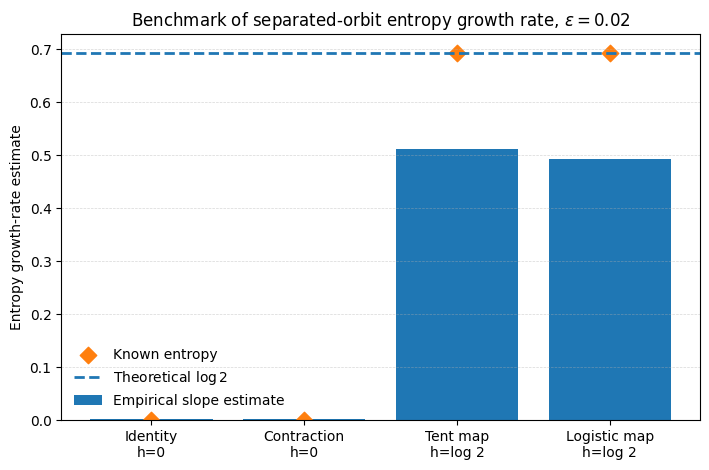


Saved manuscript figure:
benchmark_entropy_growth_rate_known_systems.jpeg
benchmark_entropy_growth_rate_known_systems.pdf


In [9]:
# ============================================================
# Manuscript figure: slope-based entropy growth-rate estimate
# ============================================================

# Epsilon used for the manuscript figure
plot_eps = 0.02 # choose from the eps values [0.005, 0.01, 0.02, 0.05, 0.1]

slope_df["system"] = pd.Categorical(
    slope_df["system"],
    categories=system_order,
    ordered=True
)

slope_df = slope_df.sort_values("system")

x = np.arange(len(slope_df))

plt.figure(figsize=(7.2, 4.8))

plt.bar(
    x,
    slope_df["slope_entropy_estimate"],
    label="Empirical slope estimate"
)

plt.scatter(
    x,
    slope_df["true_entropy"],
    marker="D",
    s=70,
    label="Known entropy"
)

plt.axhline(
    np.log(2),
    linestyle="--",
    linewidth=2,
    label=r"Theoretical $\log 2$"
)

plt.xticks(
    x,
    [pretty_names[s] for s in slope_df["system"]],
    rotation=0
)

plt.ylabel(r"Entropy growth-rate estimate")
plt.title(rf"Benchmark of separated-orbit entropy growth rate, $\epsilon={plot_eps}$")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig(figure_jpeg, dpi=900, bbox_inches="tight")
plt.savefig(figure_pdf, bbox_inches="tight")

plt.show()

print("\nSaved manuscript figure:")
print(figure_jpeg)
print(figure_pdf)

In [10]:
all_slope_rows = []

for eps in sorted(benchmark_df["epsilon"].unique()):
    for system in system_order:
        df_s = benchmark_df[
            (benchmark_df["system"] == system)
            & (benchmark_df["epsilon"] == eps)
        ].sort_values("n")

        n_vals = df_s["n"].values
        logS_vals = np.log(df_s["S_Q"].values)

        slope, intercept = np.polyfit(n_vals, logS_vals, 1)

        all_slope_rows.append({
            "epsilon": eps,
            "system": system,
            "slope_entropy_estimate": slope,
            "true_entropy": df_s["true_entropy"].iloc[0]
        })

all_slope_df = pd.DataFrame(all_slope_rows)

print(all_slope_df.pivot(
    index="system",
    columns="epsilon",
    values="slope_entropy_estimate"
))

epsilon             0.005     0.010     0.020     0.050     0.100
system                                                           
contraction_h0   0.000795  0.000458  0.002732  0.003252 -0.007571
identity_h0      0.000795  0.000458  0.002732  0.003252 -0.007571
logistic_h_log2  0.342626  0.422109  0.492381  0.563367  0.588407
tent_h_log2      0.350172  0.435942  0.512075  0.579532  0.589632
